In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [19]:
# Load data
df = pd.read_csv('homeless_deaths_by_cause_data.csv')

In [20]:
# View data
print(df.head())

   _id  Year of death                Subgroup Final_Age (group)  Gender Count
0    1           2022     Acute Drug Toxicity             20-39  Female    23
1    2           2024                 Pending               60+  Female     1
2    3           2024  Cardiovascular Disease               60+    Male     4
3    4           2023                Homicide             20-39  Female     2
4    5           2024                 Suicide             20-39    Male     2


In [21]:
# Clean data
# remove rows where Count is 'Suppressed' (small cells were redacted for privacy)
df = df[df['Count'] != 'Suppressed'].copy()
# convert Count to numeric
df['Count'] = pd.to_numeric(df['Count'])

In [23]:
# Keep only the cause-of-death rows and sumacross all years

causes = [
    "Acute Drug Toxicity",
    "Cardiovascular Disease",
    "Homicide",
    "Other Diseases",
    "Pending",
    "Suicide",
    "Unintentional Injury",
    "Unknown",
]

df_cause = df[df['Subgroup'].isin(causes)]

In [31]:
# Pivot: rows = cause, columns = year; sort by total deaths
pivot = df_cause.groupby(["Subgroup", "Year of death"])["Count"].sum().unstack(fill_value=0)
pivot = pivot.loc[pivot.sum(axis=1).sort_values().index]
pivot = pivot[sorted(pivot.columns, reverse=True)]

Text(2, -2, 'Source: City of Toronto Open Data - Deaths of People Experiencing Homelessness - Homeless Deaths by Cause')

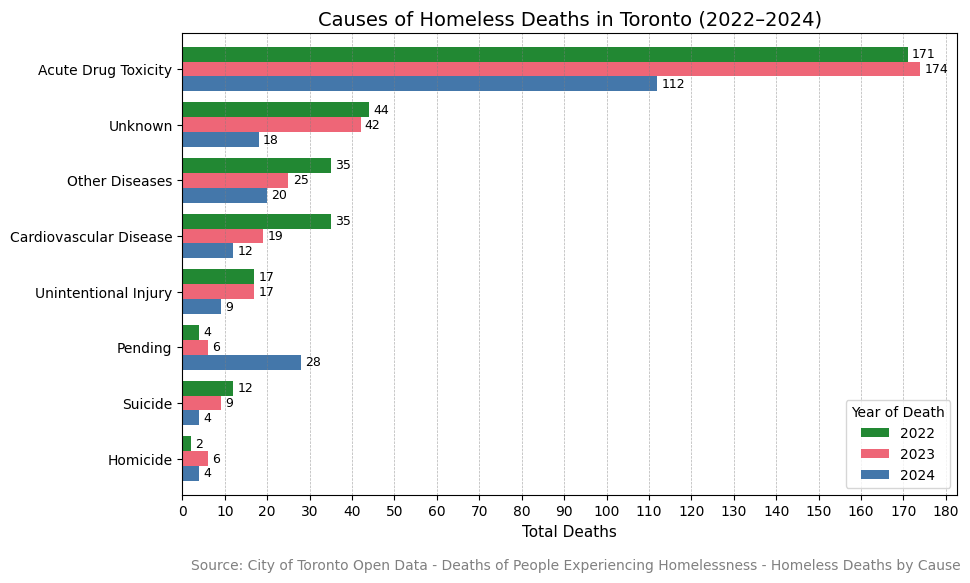

In [57]:
# Build visualization
fig, ax = plt.subplots(figsize=(10, 6))
pivot.plot(kind="barh", ax=ax, color=["#4477AA", "#EE6677", "#228833"], width=0.8)
for bar in ax.patches:
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            int(bar.get_width()), va='center', fontsize=9)
    
ax.set_title(
    "Causes of Homeless Deaths in Toronto (2022–2024)",
    fontdict={"family": "sans-serif", "size": 14}
)
plt.xlabel("Total Deaths", fontsize=11, fontdict={"family": "sans-serif"})
plt.ylabel("")
ax.xaxis.set_major_locator(plt.MultipleLocator(10))
ax.grid(axis="x", color="gray", linewidth=0.5, linestyle="--", alpha=0.6)

# Add data labels
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title="Year of Death", fontsize=10)

ax.text(2, -2, "Source: City of Toronto Open Data - Deaths of People Experiencing Homelessness - Homeless Deaths by Cause",
      ha='left',    ##alignment of text
      color = 'grey',  ##modify font colour
      size = 10)      ##modify font size



In [58]:
fig.tight_layout()
fig.savefig("homeless_deaths_by_cause.png", dpi=150, bbox_inches="tight")

fig.show()

print("Saved: homeless_deaths_by_cause.png")

Saved: homeless_deaths_by_cause.png


C:\Users\sjeon\AppData\Local\Temp\ipykernel_18592\1526849445.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
